In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd

logon = pd.read_csv("../data/r4.2/logon.csv", nrows=300000)  # restricting to 300k rows for faster processing
print(f"{logon.shape[0]} rows and {logon.shape[1]} columns")
logon.head()




300000 rows and 5 columns


,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},01/02/2010 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},01/02/2010 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},01/02/2010 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},01/02/2010 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},01/02/2010 07:00:00,MOH0273,PC-6699,Logon


In [2]:
# last 10 users who logged in 
logon.tail(10)

,id,date,user,pc,activity
299990,{J3R6-R3UP63YV-9898BUMD},06/14/2010 11:23:28,SSH0799,PC-3847,Logon
299991,{X7N2-N1GX35ZJ-8365UFQH},06/14/2010 11:26:55,TOR0193,PC-1283,Logon
299992,{V8D2-V3FQ21PX-4496WZOW},06/14/2010 11:27:11,GZC0735,PC-8219,Logon
299993,{Y4P0-M4HV64JE-1822UMJZ},06/14/2010 11:28:05,MLD0755,PC-6233,Logon
299994,{E2E5-Z6SI76KC-0902YUXS},06/14/2010 11:28:16,FFC0891,PC-4124,Logoff
299995,{F6I8-R7BZ04AJ-5545LDYZ},06/14/2010 11:28:49,JCG0316,PC-4124,Logon
299996,{Y4Y2-V4JY19VI-3363ZQHW},06/14/2010 11:30:56,EGD0409,PC-3263,Logon
299997,{C2O0-F0AY32WL-0921UQTY},06/14/2010 11:31:14,SSH0799,PC-3847,Logoff
299998,{W4X2-P8HU90ZP-9561EUEE},06/14/2010 11:31:24,FWM0707,PC-3847,Logon
299999,{T8V0-D9UN97UP-3418DONG},06/14/2010 11:33:48,JCG0316,PC-4124,Logoff


ANALYSIS OF USER LOGIN ACTIVITY FROM 01/02/2010 - 14/06/2010

In [3]:
logon.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   id        300000 non-null  str  
 1   date      300000 non-null  str  
 2   user      300000 non-null  str  
 3   pc        300000 non-null  str  
 4   activity  300000 non-null  str  
dtypes: str(5)
memory usage: 11.4 MB


In [4]:
#missing values
logon.isnull().sum()

id          0
date        0
user        0
pc          0
activity    0
dtype: int64

In [5]:
# value counts of user logging in 
logon['user'].value_counts(dropna=True)

user
BSS0369    1179
WPR0368    1119
JTM0223    1109
AJF0370    1085
CBB0365    1060
           ... 
MTT0901      78
LPH0572      74
HJS0072      73
MBW0809      60
DGM0754      58
Name: count, Length: 1000, dtype: int64

In [6]:
# first 100 users logged in for the first time
print(logon['user'].unique()[:100])

<StringArray>
['NGF0157', 'LRR0148', 'IRM0931', 'MOH0273', 'LAP0338', 'MHH0180', 'NOB0181',
 'AHC0142', 'CTR0341', 'ATE0869', 'NWK0215', 'HVB0037', 'ABC0174', 'AJR0319',
 'JKJ0698', 'JCR0172', 'HAD0246', 'RRC0553', 'IKP0472', 'BRS0734', 'HPH0075',
 'RZC0746', 'ESJ0670', 'IIW0249', 'JKF0465', 'AMW0392', 'HSB0196', 'YIC0195',
 'NAH0503', 'WPR0368', 'JDC0030', 'HDD0806', 'AOK0844', 'FKK0055', 'JHP0583',
 'RAW0915', 'SSJ0784', 'FOB0756', 'CJM0521', 'HLH0512', 'BQS0525', 'BRB0355',
 'IAR0694', 'SMH0291', 'BDI0533', 'DAR0885', 'ALB0892', 'BSS0369', 'DLM0051',
 'CMB0912', 'SBN0971', 'LBH0942', 'MLM0950', 'LBF0214', 'NAF0326', 'QOS0878',
 'TDS0984', 'RAM0447', 'EHB0420', 'DRR0242', 'NGC0058', 'OBH0499', 'MAD0496',
 'MCD0125', 'MCF0600', 'JAJ0849', 'PTH0830', 'IIL0513', 'WIQ0567', 'MDH0686',
 'LDD0560', 'BVC0790', 'NMS0280', 'JGT0221', 'MVH0373', 'MOS0047', 'JTM0223',
 'TSM0363', 'QNP0216', 'JRS0362', 'UIR0043', 'CBB0365', 'JAV0361', 'KRV0372',
 'LBC0356', 'KCF0045', 'EIS0041', 'CSC0217', 'ACC0

In [7]:
# total unique users who logged in for the first time
logon['user'].nunique(dropna=True)

1000

In [8]:
# first 20 users who logged in the most
logon['user'].value_counts().head(20)


user
BSS0369    1179
WPR0368    1119
JTM0223    1109
AJF0370    1085
CBB0365    1060
MOS0047    1044
MPM0220    1038
BAL0044    1038
EIS0041    1025
WDD0366    1008
LBC0356    1005
DMG0358     999
IBB0359     973
BBS0039     961
KRV0372     957
UIR0043     945
HDS0367     942
GTD0219     941
JGT0221     937
CSC0217     934
Name: count, dtype: int64

In [9]:

logon['user'].value_counts().tail(20)


user
CYA0506    210
HMM0108    200
OLB0749    196
LHB0606    164
AAS0442    136
CFW0264    120
CAC0889    120
DAR0885    116
BQS0525    112
JRH0455    110
EAH0466    104
LDD0560    100
CRD0624    100
EDA0684     88
ANM0123     82
MTT0901     78
LPH0572     74
HJS0072     73
MBW0809     60
DGM0754     58
Name: count, dtype: int64

In [10]:
logon.describe()

,id,date,user,pc,activity
count,300000,300000,300000,300000,300000
unique,300000,118740,1000,1002,2
top,{X1D9-S0ES98JV-5357PWMI},01/05/2010 08:00:00,BSS0369,PC-4124,Logon
freq,1,61,1179,9262,165188


In [11]:
logon['user'].value_counts()

user
BSS0369    1179
WPR0368    1119
JTM0223    1109
AJF0370    1085
CBB0365    1060
           ... 
MTT0901      78
LPH0572      74
HJS0072      73
MBW0809      60
DGM0754      58
Name: count, Length: 1000, dtype: int64

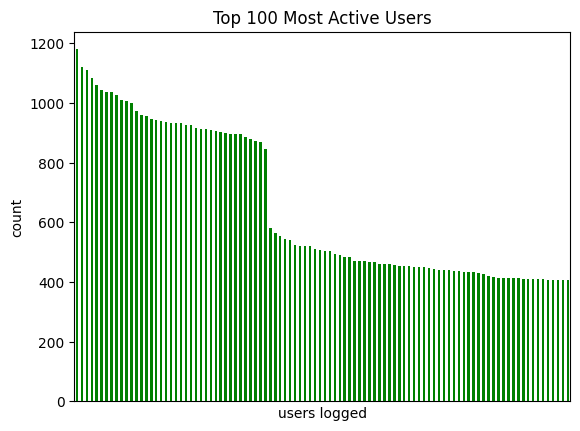

In [12]:
logon['user'].value_counts().head(100).plot(kind='bar',color='green')
plt.xticks([])
plt.title('Top 100 Most Active Users')
plt.xlabel('users logged')
plt.ylabel('count')
plt.show()

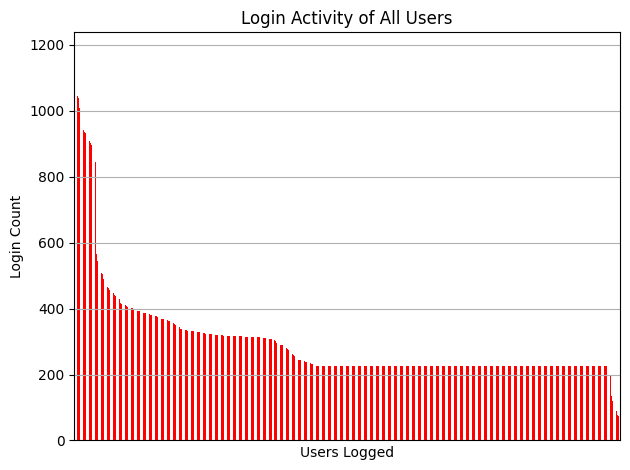

In [13]:
logon['user'].value_counts().plot(kind='bar', color='red')

plt.xticks([])
plt.title('Login Activity of All Users')
plt.xlabel('Users Logged')
plt.ylabel('Login Count')

plt.grid(axis='y')
plt.tight_layout()

plt.show()

the graph shows Some users login more frequently with(~900–1000 logins) and the normal user with (~200–400 logins)

In [14]:

logon['date']=pd.to_datetime(logon['date'])

In [15]:
logon['date'].isnull().sum

<bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
299995    False
299996    False
299997    False
299998    False
299999    False
Name: date, Length: 300000, dtype: bool>

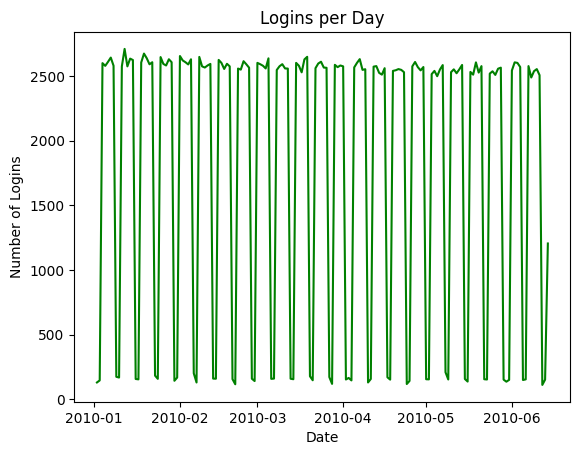

In [16]:
# logins per day 
logon.groupby(logon['date'].dt.date).size().plot(color='green')

plt.title("Logins per Day")
plt.xlabel("Date")
plt.ylabel("Number of Logins")
plt.show()

In [17]:
logon['hour'].plot(kind='hist')
plt.xlabel('hours')
plt.ylabel('no of logins')

KeyError: 'hour'

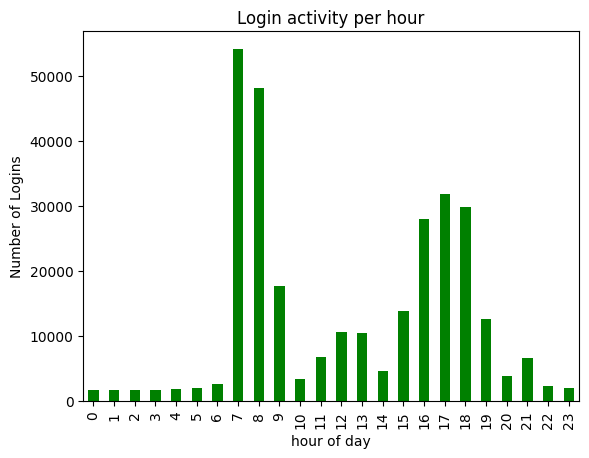

In [ ]:
logon['hour'] = logon['date'].dt.hour
logon.groupby(logon['date'].dt.hour).size().plot(kind='bar',color='green')
plt.title("Login activity per hour")
plt.xlabel("hour of day")
plt.ylabel("Number of Logins")
plt.show()

the above graph shows normal logins at 7- 8 hours and agin at 16-18 hours at the day

ANALYSIS OF USER LOGOFF ACTIVITY FROM 01/02/2010 - 14/06/2010

In [ ]:
logoff=logon[logon['activity']=='Logoff']
logoff.shape



(134812, 6)

In [ ]:
logoff.info()


<class 'pandas.DataFrame'>
Index: 134812 entries, 10 to 299999
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        134812 non-null  str           
 1   date      134812 non-null  datetime64[us]
 2   user      134812 non-null  str           
 3   pc        134812 non-null  str           
 4   activity  134812 non-null  str           
 5   hour      134812 non-null  int32         
dtypes: datetime64[us](1), int32(1), str(4)
memory usage: 6.7 MB


In [ ]:
logoff.head()

,id,date,user,pc,activity,hour
10,{S6C5-Q8LQ18VJ-5964MXZD},2010-01-02 07:24:53,LRR0148,PC-4124,Logoff,7
21,{C8O2-W2WK72JT-7595MCKX},2010-01-02 07:46:55,NOB0181,PC-4124,Logoff,7
31,{Y3O8-G3RQ78NY-4956VLZZ},2010-01-02 07:58:29,IKP0472,PC-4124,Logoff,7
38,{Q3W2-Z7JN57XZ-9964UHZP},2010-01-02 08:16:18,IRM0931,PC-4124,Logoff,8
81,{X1A2-X8KM97SR-4368YURY},2010-01-02 14:08:41,WPR0368,PC-2173,Logoff,14


In [ ]:
logoff.tail()

,id,date,user,pc,activity,hour
299988,{G8Z2-D3YF69FZ-8668VANC},2010-06-14 11:21:44,KSP0357,PC-3742,Logoff,11
299989,{H2H4-P0UO80BC-8399PNLS},2010-06-14 11:23:10,TET0621,PC-3847,Logoff,11
299994,{E2E5-Z6SI76KC-0902YUXS},2010-06-14 11:28:16,FFC0891,PC-4124,Logoff,11
299997,{C2O0-F0AY32WL-0921UQTY},2010-06-14 11:31:14,SSH0799,PC-3847,Logoff,11
299999,{T8V0-D9UN97UP-3418DONG},2010-06-14 11:33:48,JCG0316,PC-4124,Logoff,11


In [ ]:
logoff['user'].value_counts()

user
BSS0369    589
WPR0368    559
JTM0223    507
AJF0370    496
CBB0365    488
          ... 
ANM0123     32
MBW0809     30
DGM0754     29
MTT0901     29
HJS0072     27
Name: count, Length: 1000, dtype: int64

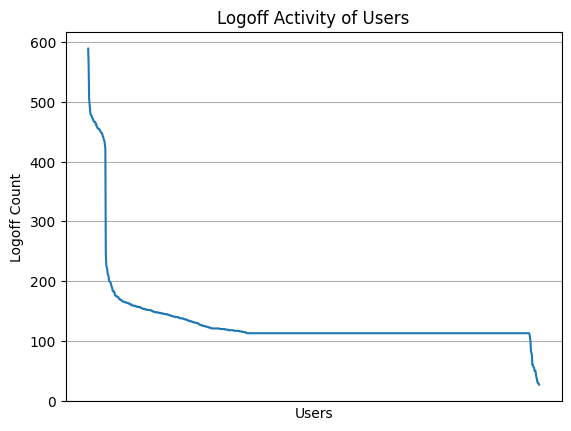

In [ ]:
logoff['user'].value_counts().plot()
plt.xticks([])
plt.title("Logoff Activity of Users")
plt.xlabel("Users")
plt.ylabel("Logoff Count")
plt.grid(axis='y')
plt.show()

this graph shows the highest logoff of a user with ~ 590 logoffs and average with ~130 logoffs

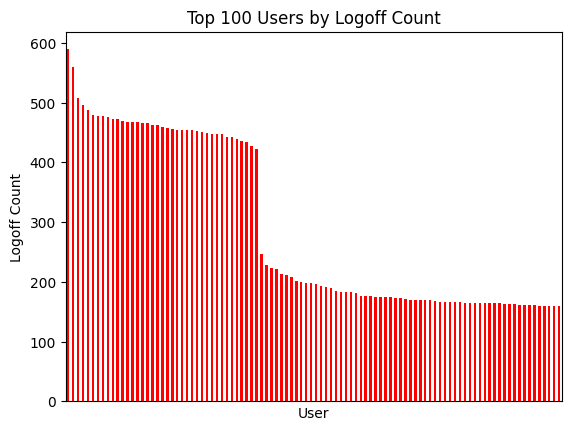

In [ ]:
logoff['user'].value_counts().head(100).plot(kind='bar',color='red')
plt.xticks([])
plt.title("Top 100 Users by Logoff Count")
plt.xlabel("User")
plt.ylabel("Logoff Count")
plt.show()

the above graph shows the top logoff users which means highuse of systems can be outliers with avegage logoff count ~ 480


In [ ]:
logoff.groupby(logoff['date'].dt.date).size()

date
2010-01-02      52
2010-01-03      57
2010-01-04    1182
2010-01-05    1134
2010-01-06    1232
              ... 
2010-06-10    1173
2010-06-11    1107
2010-06-12      46
2010-06-13      61
2010-06-14     104
Length: 164, dtype: int64

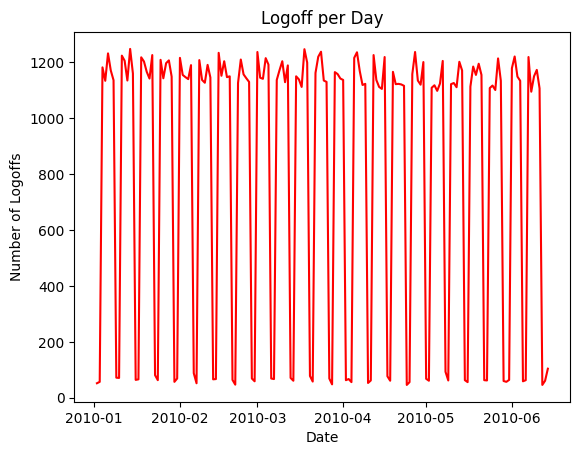

In [ ]:
logoff.groupby(logoff['date'].dt.date).size().plot(color='red')

plt.title("Logoff per Day")
plt.xlabel("Date")
plt.ylabel("Number of Logoffs")
plt.show()

In [ ]:
logoff['hour'].value_counts().sort_index()

hour
0       794
1       835
2       845
3       865
4       918
5      1073
6      1081
7      1212
8       800
9       616
10      664
11      823
12      868
13      662
14      601
15    13026
16    27228
17    30929
18    28819
19    11606
20     2770
21     5535
22     1146
23     1096
Name: count, dtype: int64

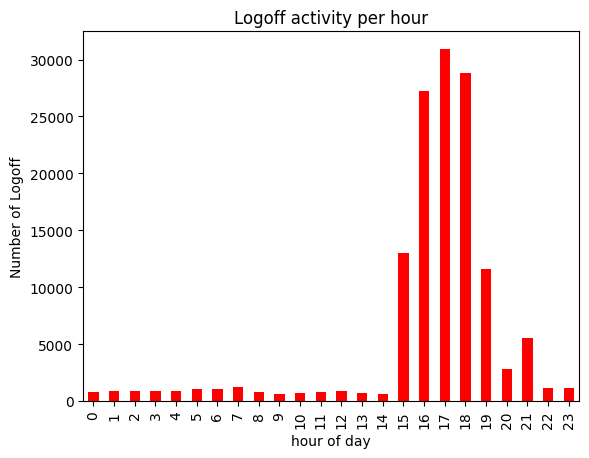

In [ ]:
logoff['date']=pd.to_datetime(logoff['date'])
logoff['hour'] = logoff['date'].dt.hour
logoff.groupby(logoff['date'].dt.hour).size().plot(kind='bar',color='red')
plt.title("Logoff activity per hour")
plt.xlabel("hour of day")
plt.ylabel("Number of Logoff")
plt.show()

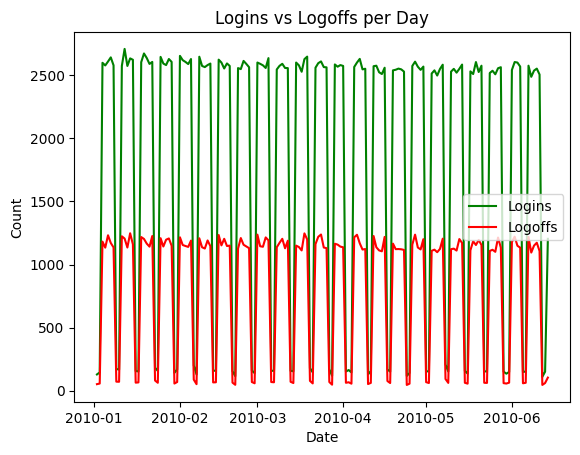

In [ ]:
# login vs logoff's per day 
logins_per_day = logon.groupby(logon['date'].dt.date).size()
logoffs_per_day = logoff.groupby(logoff['date'].dt.date).size()

plt.plot(logins_per_day, label='Logins',color='green')
plt.plot(logoffs_per_day, label='Logoffs',color='red')

plt.legend()
plt.title("Logins vs Logoffs per Day")
plt.xlabel("Date")
plt.ylabel("Count")

plt.show()

Logins (green) ≈ 2500–2700 per day
Logoffs (red) ≈ 1100–1300 per day and there is no sudden spikes in logins so its  normal working behaviour .

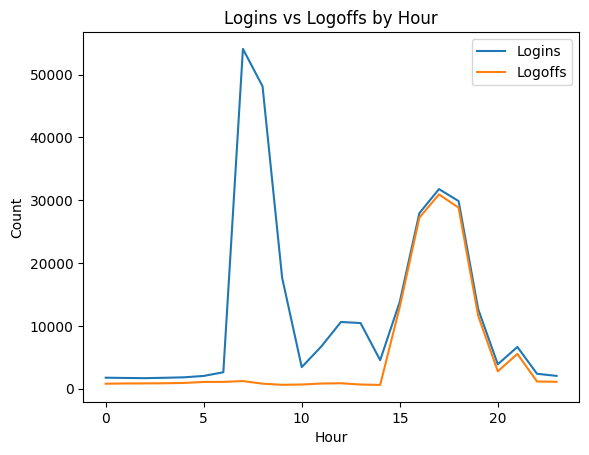

In [ ]:
login_hour = logon['hour'].value_counts().sort_index()
logoff_hour = logoff['hour'].value_counts().sort_index()

plt.plot(login_hour, label='Logins')
plt.plot(logoff_hour, label='Logoffs')

plt.legend()
plt.title("Logins vs Logoffs by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.show()

he blue line shows a huge spike in logins around:
6 AM → 54,000 logins
7 AM → ~48,000 logins
he orange line shows maximum logoffs around 16–18 hours:
4 PM → ~27,000
5 PM → ~31,000
6 PM → ~29,000
Conclusion
Most users leave the system around evening hours, which reflects normal working hours.
